In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
class logistic_regression: 
    def __init__(self, learning_rate=0.001, n_iters=1000, regularization_strength=0.01):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.lambda_ = regularization_strength
        self.weights = None
        self.bias = None
        self.losses = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def compute_loss(self, y_true, y_pred):
        # Binary cross entropy + L2 regularization
        epsilon = 1e-9
        bce = -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
        l2_penalty = (self.lambda_ / (2 * len(y_true))) * np.sum(self.weights ** 2)
        return bce + l2_penalty
    
    def feed_forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iters):
            A = self.feed_forward(X)
            loss = self.compute_loss(y, A)
            self.losses.append(loss)
            
            dz = A - y
            dw = (1 / n_samples) * np.dot(X.T, dz) + (self.lambda_ / n_samples) * self.weights  # L2 regularization term
            db = (1 / n_samples) * np.sum(dz)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
    def predict(self, X):
        y_hat = self.sigmoid(np.dot(X, self.weights) + self.bias)
        return np.array([1 if i > 0.5 else 0 for i in y_hat])

        

### Let's use our model for spam classification problem 

In [3]:
df = pd.read_csv('spam_detection_dataset.csv')

In [4]:
df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


<Axes: >

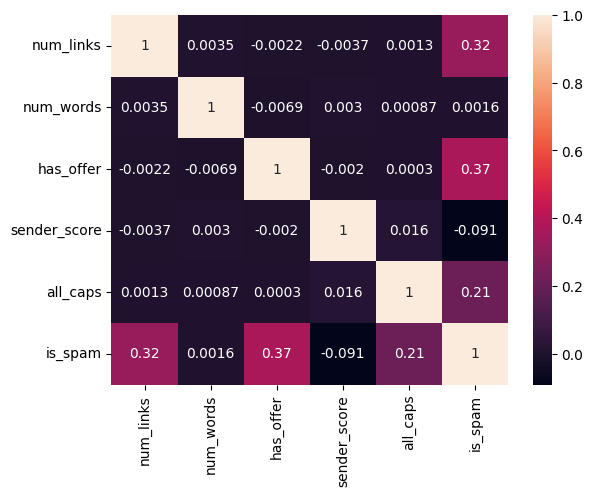

In [5]:
sns.heatmap(df.corr(), annot = True)

### It's quite clear that except num_words and sender_score all the other features have strong correlation with the target variable

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [7]:
df.isna().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(['is_spam'], axis=1), df['is_spam'], test_size=0.2, random_state=20)

In [9]:
lr_model = logistic_regression()
lr_model.fit(X_train, y_train)

In [10]:
y_prediction = lr_model.predict(X_test)

In [11]:
import numpy as np

class EvaluationMetrics:
    def __init__(self, y_true, y_pred):
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.tp = np.sum((self.y_true == 1) & (self.y_pred == 1))
        self.tn = np.sum((self.y_true == 0) & (self.y_pred == 0))
        self.fp = np.sum((self.y_true == 0) & (self.y_pred == 1))
        self.fn = np.sum((self.y_true == 1) & (self.y_pred == 0))

    def accuracy(self):
        return (self.tp + self.tn) / len(self.y_true)

    def precision(self):
        return self.tp / (self.tp + self.fp + 1e-9)  # Add epsilon to avoid div by zero

    def recall(self):
        return self.tp / (self.tp + self.fn + 1e-9)

    def f1_score(self):
        prec = self.precision()
        rec = self.recall()
        return 2 * (prec * rec) / (prec + rec + 1e-9)

    def print_metrics(self):
        print(f"Accuracy : {self.accuracy():.4f}")
        print(f"Precision: {self.precision():.4f}")
        print(f"Recall   : {self.recall():.4f}")
        print(f"F1 Score : {self.f1_score():.4f}")
    

In [12]:


# Evaluate
eval = EvaluationMetrics(y_test, y_prediction)
eval.print_metrics()


Accuracy : 0.9073
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


In [13]:
df.groupby('is_spam')['is_spam'].count()

is_spam
0    18165
1     1835
Name: is_spam, dtype: int64

In [32]:
def scale_numerical_features(df: pd.DataFrame, target_column: str) -> pd.DataFrame:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_column in numerical_cols:
        numerical_cols.remove(target_column)
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    return df

df = scale_numerical_features(df, target_column="is_spam")

In [33]:
X = df.drop('is_spam',axis=1)
y = df['is_spam']

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [51]:
y.value_counts()


is_spam
0    18165
1    18165
Name: count, dtype: int64

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regressor = logistic_regression()
regressor.fit(X_train, y_train)

In [36]:
y_pred_ = regressor.predict(X_test)

In [37]:
eval = EvaluationMetrics(y_test, y_pred_)
eval.print_metrics()


Accuracy : 0.8156
Precision: 0.7372
Recall   : 0.9838
F1 Score : 0.8429


Accuracy: 0.8787503440682631
Precision: 0.8747971876690103
Recall: 0.8855735012318642
F1-score: 0.880152360223099


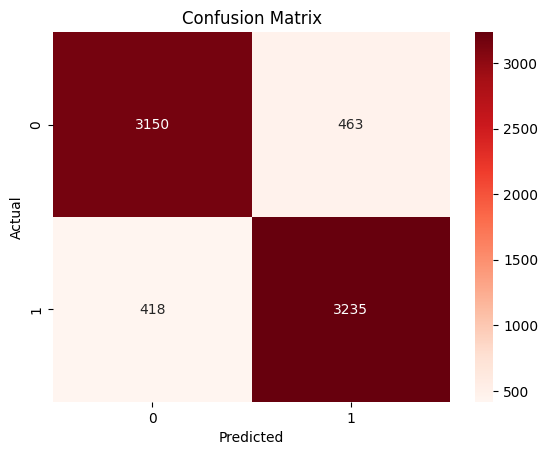

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      3613
           1       0.87      0.89      0.88      3653

    accuracy                           0.88      7266
   macro avg       0.88      0.88      0.88      7266
weighted avg       0.88      0.88      0.88      7266



In [48]:
model = LogisticRegression(penalty='l2') 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Reds', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))